In [1]:
# Colab 모두 실행용 셋업 셀
# 이 셀은 런타임 → 모두 실행을 눌렀을 때 필요한 파일/폴더/패키지를 자동으로 준비합니다.

import os
import sys
import subprocess
import zipfile
import urllib.request
from pathlib import Path

# 기본값은 Colab에서 끊기지 않고 끝까지 도는 빠른 실행 모드입니다.
# 그래프가 선으로 보이도록 epoch 기본값은 3으로 설정했습니다.
# 전체 데이터로 오래 학습하려면 아래 값을 "0"으로 바꾸면 됩니다.
os.environ.setdefault("BERT_PRETRAIN_FAST_RUN", "1")
os.environ.setdefault("BERT_PRETRAIN_MAX_LINES", "20000")
os.environ.setdefault("BERT_PRETRAIN_COUNT", "4096")
os.environ.setdefault("BERT_PRETRAIN_EPOCHS", "50")
os.environ.setdefault("BERT_PRETRAIN_BATCH_SIZE", "8")
os.environ.setdefault("BERT_PRETRAIN_SP_VOCAB_SIZE", "8000")

# 패키지 설치
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "sentencepiece", "tqdm", "torchinfo"
])

BASE_DIR = Path("/content") if Path("/content").exists() else Path.cwd()
os.chdir(BASE_DIR)

DATA_DIR = BASE_DIR / "data"
MODEL_DIR = BASE_DIR / "models"
WORK_DIR = BASE_DIR / "work"
for path in (DATA_DIR, MODEL_DIR, WORK_DIR):
    path.mkdir(parents=True, exist_ok=True)

CORPUS_URL = "https://d3s0tskafalll9.cloudfront.net/media/documents/kowiki.txt.zip"
zip_path = DATA_DIR / "kowiki.txt.zip"
corpus_path = DATA_DIR / "kowiki.txt"

# corpus 다운로드 및 압축 해제
if not corpus_path.exists():
    try:
        if not zip_path.exists():
            print("Downloading kowiki.txt.zip...")
            urllib.request.urlretrieve(CORPUS_URL, zip_path)

        print("Extracting kowiki.txt.zip...")
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(DATA_DIR)

        found = list(DATA_DIR.rglob("kowiki.txt"))
        if found:
            found_path = found[0]
            if found_path != corpus_path:
                corpus_path.write_text(found_path.read_text(encoding="utf-8"), encoding="utf-8")
    except Exception as e:
        print("kowiki.txt 다운로드에 실패해 샘플 corpus로 대체합니다.")
        print("실제 학습을 하려면 data/kowiki.txt를 직접 업로드하세요.")
        sample_text = """
인공지능은 컴퓨터가 사람처럼 학습하고 추론하도록 만드는 기술이다.
자연어 처리는 사람이 사용하는 언어를 컴퓨터가 이해하도록 만드는 분야이다.
BERT는 Transformer encoder 구조를 기반으로 만들어진 언어 모델이다.
Masked Language Modeling은 일부 토큰을 가리고 원래 토큰을 맞히는 학습 방식이다.
Next Sentence Prediction은 두 문장이 이어지는지 판단하는 학습 방식이다.

딥러닝 모델은 많은 데이터를 사용하여 패턴을 학습한다.
토크나이저는 문장을 작은 단위의 토큰으로 나누는 역할을 한다.
SentencePiece는 subword 기반 토크나이저를 만들 때 자주 사용된다.
""".strip()
        corpus_path.write_text((sample_text + "\n\n") * 2000, encoding="utf-8")

# 빠른 실행 모드에서는 corpus 일부만 사용합니다.
fast_run = os.environ.get("BERT_PRETRAIN_FAST_RUN", "1") == "1"
if fast_run:
    max_lines = int(os.environ.get("BERT_PRETRAIN_MAX_LINES", "20000"))
    run_corpus_path = DATA_DIR / "kowiki_colab_small.txt"
    if not run_corpus_path.exists():
        print(f"Creating small corpus for fast run: first {max_lines} lines")
        with open(corpus_path, "r", encoding="utf-8") as in_f, open(run_corpus_path, "w", encoding="utf-8") as out_f:
            for i, line in enumerate(in_f):
                if i >= max_lines:
                    break
                out_f.write(line)
else:
    run_corpus_path = corpus_path

os.environ["BERT_PRETRAIN_CORPUS_FILE"] = str(run_corpus_path)

# SentencePiece 모델이 없으면 자동 생성합니다.
# 빠른 실행을 위해 기본 vocab size는 8000으로 둡니다.
import sentencepiece as spm
model_path = DATA_DIR / "ko_32000.model"
if not model_path.exists() and not (MODEL_DIR / "ko_32000.model").exists():
    sp_vocab_size = int(os.environ.get("BERT_PRETRAIN_SP_VOCAB_SIZE", "8000"))
    prefix = DATA_DIR / "ko_32000"
    print(f"Training SentencePiece model. vocab_size={sp_vocab_size + 7}")
    spm.SentencePieceTrainer.train(
        f"--input={run_corpus_path} "
        f"--model_prefix={prefix} "
        f"--vocab_size={sp_vocab_size + 7} "
        "--model_type=bpe "
        "--max_sentence_length=999999 "
        "--pad_id=0 --pad_piece=[PAD] "
        "--unk_id=1 --unk_piece=[UNK] "
        "--bos_id=2 --bos_piece=[BOS] "
        "--eos_id=3 --eos_piece=[EOS] "
        "--user_defined_symbols=[SEP],[CLS],[MASK] "
        "--hard_vocab_limit=false"
    )

print("Colab setup finished.")
print("corpus_file:", os.environ["BERT_PRETRAIN_CORPUS_FILE"])
print("fast_run:", fast_run)
print("train_count:", os.environ["BERT_PRETRAIN_COUNT"])
print("epochs:", os.environ["BERT_PRETRAIN_EPOCHS"])
print("batch_size:", os.environ["BERT_PRETRAIN_BATCH_SIZE"])


Colab setup finished.
corpus_file: /home/jovyan/work/AIFFEL_quest_eng/NLP/NLP04/data/kowiki_colab_small.txt
fast_run: True
train_count: 4096
epochs: 50
batch_size: 8


# 1. 들어가며

![](https://resources-public-prd.modulabs.co.kr/home-section/story-modulabs-articles-section/b011bc6a-e1d9-4e87-b252-fa90d7229cc7.png)

지난 시간 우리는 transformer 기반의 pretrained model의 발전사를 살펴보고, 어떻게 이 모델들이 맥락 기반의 word representation을 구성할 수 있으며 또한 Transfer learning을 통해 다양한 자연어 처리 문제를 쉽게 해결할 수 있는지 살펴보았습니다.

이런 모델들을 만들어 내기 위해서는 아주 큰 사이즈의 모델이 필요합니다. 가장 대표적인 BERT만 하더라도 정식 모델은 340M나 되는 파라미터 사이즈를 자랑합니다. 이들을 수십 GB나 되는 코퍼스를 토대로 학습시키는 것은 최고 성능의 GPU를 가지고도 수일 내지 수 주일의 시간이 걸립니다. 아마도 여러분 대부분의 학습환경에서 이를 수행하는 것은 가능한 일이 아닐 것입니다.

그래서 오늘은 일반적인 10M 정도의 작은 파라미터 사이즈의 BERT 모델을 만들어, 수백 MB 수준의 코퍼스 기반으로 pretrain 을 진행해 보도록 하겠습니다. 하지만 진행되는 과정은 정식 BERT와 동일할 테니 이를 토대로 pretrained model이 어떻게 만들어지는지를 경험해 보도록 합시다. 모델을 만들고 학습시키는 것 이상으로 코퍼스 데이터를 가공해서 학습시켜야 할 task에 적합한 형태의 데이터셋으로 만들어가는 것이 큰 비중을 차지한다는 것을 알게 될 것입니다.

오늘의 작업을 위해 다음과 같이 작업환경을 마련해 주세요. 학습에 사용할 코퍼스 데이터를 아래에 첨부해 두었습니다.

## 데이터 다운로드
---
[kowiki.txt.zip](https://d3s0tskafalll9.cloudfront.net/media/documents/kowiki.txt.zip)

```
$ mkdir -p ~/work/bert_pretrain/data
$ mkdir -p ~/work/bert_pretrain/models
$ wget https://aiffelstaticprd.blob.core.windows.net/media/documents/kowiki.txt.zip
$ mv kowiki.txt.zip ~/work/bert_pretrain/data
$ cd ~/work/bert_pretrain/data && unzip kowiki.txt.zip
```

혹시 이번 실습에서 필요한 아래 라이브러리가 없다면 미리 설치해 주세요.


```
$ pip install sentencepiece
$ pip install tqdm
$ conda install -c conda-forge ipywidgets
$ jupyter nbextension enable --py widgetsnbextension
```

In [2]:
#로컬에서 진행하실 경우 다음과 같이 경로설정을 합니다
#!mkdir data
#!mkdir models

In [3]:
#LMS에는 데이터가 준비되어 있습니다
#!wget https://d3s0tskafalll9.cloudfront.net/media/documents/kowiki.txt.zip

In [4]:
#LMS에는 데이터가 준비되어 있습니다
#!mv kowiki.txt.zip /content/data

In [5]:
#LMS에는 데이터가 압축이 풀린 채로 준비되어 있습니다.
#%cd /content/data
#!unzip kowiki.txt.zip

In [6]:
# 다음 라이브러리를 설치해주세요.
# Jupyter 환경에서는 !pip보다 %pip가 현재 커널에 더 안전하게 설치합니다.
%pip install -q sentencepiece tqdm torchinfo

Note: you may need to restart the kernel to use updated packages.


## 학습 내용
---

- **2. Tokenizer 준비**
  - BPE를 바탕으로 단어를 분석해봐요.
- **3. 데이터 전처리**
  - **(1) MASK 생성**
    - Masked LM은 어떻게 만들까요?
  - **(2) NSP pair 생성**
    - 다음에 이어질 문장으로 가장 적절한 것을 고르시오.
  - **(3) 데이터셋 완성**
    - NSP에 맞게 데이터셋도 다시 만들어봐요.
- **4. BERT 모델 구현**
  - 나만의 작고 소중한 BERT
- **5. pretrain 진행**
  - 그 유명한 pretrained model, 제가 한 번 만들어 볼게요.

## 학습 목표
---
- BERT 모델을 구현하고 훈련시킬 수 있다.
- BERT에 사용된 masking 기법들을 이해하고 구현할 수 있다.
- NSP task를 이해하고, 데이터셋을 이에 맞게 구성할 수 있다.

# 2. Tokenizer 준비

BERT등의 pretrained model이 나오게 되었을 즈음 자연어처리 분야의 또 다른 중요한 흐름 중 하나는 BPE 등의 subword 기반의 토크나이징 기법이 주요한 방법론으로 굳어졌다는 점입니다. GPT의 BPE, BERT의 WordPiece 모델 등의 성공이 더욱 사람들에게 subword 기반의 토크나이저에 대한 확신을 주었습니다.

오늘 우리는 [SentencePiece](https://github.com/google/sentencepiece) 기반의 토크나이저를 준비하는 것으로 BERT pretrain 과정을 시작할 것입니다. 이 과정 자체는 이미 익숙하실 것이라 생각합니다.

In [7]:
# imports
from __future__ import absolute_import, division, print_function, unicode_literals

import os
import re
import math
import random
import collections
import json
import shutil
import zipfile
import copy
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import sentencepiece as spm
from tqdm.auto import tqdm

random_seed = 1234
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)

# torch version
print(torch.__version__)

2.7.1+cu118


준비해 둔 한글 나무위키 코퍼스로부터 32000의 vocab_size를 갖는 sentencepiece 모델을 생성해 보겠습니다.

BERT에 사용되는 `[MASK]`, `[SEP]`, `[CLS]` 등의 주요 특수문자가 vocab에 포함되어야 함에 주의해 주세요. 아래와 같이 모델을 생성하게 되면 약 30분 정도가 소요될 것입니다. **그래서 아래 코드는 보기만하고 넘어가고 미리 만들어 놓은 파일을 아래 처럼 따라하여 사용하겠습니다.**

(선택) 직접 model 과 vocab 을 만들기 : cloud shell을 열어 아래 코드를 한줄씩 실행해주세요.



```
$ python
>>> import sentencepiece as spm
>>> import os
>>> corpus_file = os.getenv('HOME')+'/work/bert_pretrain/data/kowiki.txt'
>>> prefix = os.getenv('HOME')+'/work/bert_pretrain/models/ko_32000'
>>> vocab_size = 32000
>>> spm.SentencePieceTrainer.train(f"--input={corpus_file} --model_prefix={prefix} --vocab_size={vocab_size + 7} --model_type=bpe --max_sentence_length=999999 --pad_id=0 --pad_piece=[PAD] --unk_id=1 --unk_piece=[UNK] --bos_id=2 --bos_piece=[BOS] --eos_id=3 --eos_piece=[EOS] --user_defined_symbols=[SEP],[CLS],[MASK]")
```

SentencePieceTrainer 에 전달하는 파라미터 설명은 [setencepiece/doc/options.md](https://github.com/google/sentencepiece/blob/master/doc/options.md) 를 확인하세요.


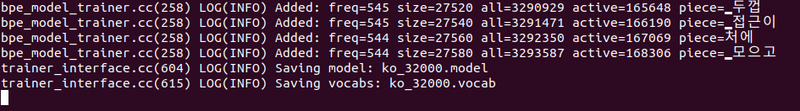

> 이미지와 같이 터미널에서 `ko_32000.model`, `ko_32000.vocab` 생성을 확인할 수 있습니다.

sentencepiece 모델 학습이 끝난 후 생성된 `ko_32000.model`, `ko_32000.vocab` 두 파일은 커널이 생성되었을 때의 홈 디렉토리에 생성되었을 것입니다. 이 두 파일을 `~/work/bert_pretrain/models` 아래로 이동시킨 후 계속 진행해 주세요.



```
# 홈 디렉토리에서 아래 명령어를 입력해 주세요.
$ mv ko_32000.* ~/work/bert_pretrain/models
```



In [8]:
import sentencepiece as spm
from pathlib import Path

# Colab setup cell에서 지정한 corpus 파일을 사용합니다.
data_dir = Path("data")
model_dir = Path("models")
corpus_file = Path(os.environ.get("BERT_PRETRAIN_CORPUS_FILE", str(data_dir / "kowiki.txt")))
prefix = data_dir / "ko_32000"
vocab_size = 32000

# SentencePiece 모델은 첫 번째 Colab setup cell에서 자동 생성됩니다.
# 직접 만들고 싶으면 아래 코드를 참고해 주석을 해제하면 됩니다.
# spm.SentencePieceTrainer.train(
#     f"--input={corpus_file} "
#     f"--model_prefix={prefix} "
#     f"--vocab_size={vocab_size + 7} "
#     "--model_type=bpe "
#     "--max_sentence_length=999999 "
#     "--pad_id=0 --pad_piece=[PAD] "
#     "--unk_id=1 --unk_piece=[UNK] "
#     "--bos_id=2 --bos_piece=[BOS] "
#     "--eos_id=3 --eos_piece=[EOS] "
#     "--user_defined_symbols=[SEP],[CLS],[MASK] "
#     "--hard_vocab_limit=false"
# )


In [9]:
# vocab loading
candidate_model_paths = [
    data_dir / "ko_32000.model",
    model_dir / "ko_32000.model",
]
model_path = next((path for path in candidate_model_paths if path.exists()), None)

if model_path is None:
    raise FileNotFoundError(
        "ko_32000.model을 찾을 수 없습니다. "
        "첫 번째 Colab setup cell이 정상적으로 실행되었는지 확인하세요."
    )

vocab = spm.SentencePieceProcessor()
vocab.load(str(model_path))
REAL_VOCAB_SIZE = vocab.get_piece_size()
print("Loaded SentencePiece model:", model_path)
print("REAL_VOCAB_SIZE:", REAL_VOCAB_SIZE)


Loaded SentencePiece model: data/ko_32000.model
REAL_VOCAB_SIZE: 8007


토크나이저가 잘 만들어졌는지 확인해 봅시다. 어떤 토큰이 만들어졌는지, 토크나이징 결과가 어떻게 나오는지 살펴볼까요?

In [10]:
# Q. 특수 token 7개를 제외한 나머지 token들을 출력해봅시다.
vocab_list = []
for token_id in range(7, vocab.get_piece_size()):
    if not vocab.is_unknown(token_id):
        vocab_list.append(vocab.id_to_piece(token_id))

print("vocab_list size:", len(vocab_list))
print(vocab_list[:100])


vocab_list size: 8000
['▁이', '▁1', '으로', '▁있', '에서', '▁그', '▁대', '▁사', '▁수', '▁2', '었다', '▁기', '▁가', '▁한', '▁전', '▁정', '▁지', '▁있다', '하는', '▁19', '하였', '▁아', '▁다', '▁시', '했다', '▁것', '▁중', '▁일', '이다', '▁자', '▁제', '▁유', '▁공', '▁인', '▁주', '▁하', '▁등', '하였다', '▁경', '▁위', '하고', '하여', '00', '▁의', '▁국', '되었다', '▁보', '한다', '▁나', '▁연', '▁발', '▁비', '에는', '▁조', '▁소', '▁모', '▁개', '▁부', '▁영', '으며', '▁미', '▁때', '▁3', '▁동', '▁세', '▁관', '▁해', '▁구', '적인', '▁오', '▁여', '▁고', '▁상', '▁문', '▁서', '▁같', '▁않', 'or', '▁도', '▁대한', '적으로', '▁만', '▁방', '▁선', '▁"', '▁사용', '▁통', '▁또', '▁생', '▁프', 'la', '이라', '▁마', '▁내', '▁따', '▁성', '▁후', '▁실', '▁스', '▁신']


In [11]:
# [CLS], tokens a, [SEP], tokens b, [SEP] 형태의 token 생성
string_a = "추적추적 비가 내리는 날이었어 그날은 왠지 손님이 많아 첫 번에 삼십 전 둘째번 오십 전 오랜만에 받아보는 십 전짜리 백통화 서푼에"
string_b = "손바닥 위엔 기쁨의 눈물이 흘러 컬컬한 목에 모주 한잔을 적셔 몇 달 포 전부터 콜록거리는 아내 생각에 그토록 먹고 싶다던"
tokens_org = ["[CLS]"] + vocab.encode_as_pieces(string_a) + ["[SEP]"] + vocab.encode_as_pieces(string_b) + ["[SEP]"]
print(tokens_org)

['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많아', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘째', '번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전', '부터', '▁콜', '록', '거', '리는', '▁아내', '▁생각', '에', '▁그', '토', '록', '▁먹', '고', '▁싶', '다', '던', '[SEP]']


토크나이저가 잘 작동하나요? 방금 우리는 SentencePiece 모델을 이용해 간단한 BERT의 Masked Language Model 학습용 데이터를 하나 생성해 보았습니다.

다음 절부터 본격적으로 데이터 전처리 과정에 돌입하겠습니다.

# 3. 데이터 전처리
## (1) MASK 생성

BERT의 Masked Language Model(MLM)은 GPT의 Next Token Prediction 태스크처럼 `다음이 이어질 단어는?` 을 맞추는 게 아니라 마스킹 된 `다음 빈칸에 알맞은 단어는?` 문제를 푸는 형식으로 구성됩니다.

MLM을 위해 BERT는 학습 데이터의 전체에서 15%를 `[MASK]` 토큰으로 랜덤하게 바꿉니다. 이 15%의 `[MASK]` 토큰 중 80%는 `[MASK]` 토큰, 10%는 무작위로 랜덤한 토큰, 나머지 10%는 원래의 토큰을 그대로 사용합니다.

이전 스텝의 Masked LM 데이터셋 예시에서 출발해 봅시다.

In [12]:
print(tokens_org)

# 전체 token의 15% mask
mask_cnt = int((len(tokens_org) - 3) * 0.15)
mask_cnt

['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많아', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘째', '번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전', '부터', '▁콜', '록', '거', '리는', '▁아내', '▁생각', '에', '▁그', '토', '록', '▁먹', '고', '▁싶', '다', '던', '[SEP]']


13

15%를 마스킹 한다고 해도 생각해 볼 것이 더 있습니다. Subword 기반으로 토크나이징을 했을 때 `_대, [MASK], 민국`이라고 가운데를 마스킹 했을 경우 해당 `[MASK]`가 '한'일 거라는 건 너무 쉽게 맞출 수 있습니다. '대한민국'이라는 패턴을 아주 자주 보게 될 테니까요.

그래서 Masked LM 태스크를 구성할 땐 **띄어쓰기 단위로 한꺼번에 마스킹**해 주는 것이 좋습니다. 다음과 같이 처리합니다.

In [13]:
# 띄어쓰기 단위로 mask하기 위해서 index 분할
cand_idx = []  # word 단위의 index array
for (i, token) in enumerate(tokens_org):
    if token == "[CLS]" or token == "[SEP]":
        continue
    if 0 < len(cand_idx) and not token.startswith(u"\u2581"):  # u"\u2581"는 단어의 시작을 의미하는 값
        cand_idx[-1].append(i)
    else:
        cand_idx.append([i])

# 결과확인
for cand in cand_idx:
    print(cand, [tokens_org[i] for i in cand])

[1, 2, 3, 4] ['▁추', '적', '추', '적']
[5, 6] ['▁비', '가']
[7, 8] ['▁내', '리는']
[9, 10, 11] ['▁날', '이었', '어']
[12, 13, 14] ['▁그', '날', '은']
[15, 16, 17] ['▁', '왠', '지']
[18, 19, 20] ['▁손', '님', '이']
[21] ['▁많아']
[22] ['▁첫']
[23, 24] ['▁번', '에']
[25, 26] ['▁삼', '십']
[27] ['▁전']
[28, 29] ['▁둘째', '번']
[30, 31] ['▁오', '십']
[32] ['▁전']
[33, 34] ['▁오랜', '만에']
[35, 36] ['▁받아', '보는']
[37] ['▁십']
[38, 39, 40] ['▁전', '짜', '리']
[41, 42, 43] ['▁백', '통', '화']
[44, 45, 46] ['▁서', '푼', '에']
[48, 49, 50] ['▁손', '바', '닥']
[51, 52] ['▁위', '엔']
[53, 54, 55] ['▁기', '쁨', '의']
[56, 57] ['▁눈', '물이']
[58, 59] ['▁흘', '러']
[60, 61, 62] ['▁컬', '컬', '한']
[63, 64] ['▁목', '에']
[65, 66] ['▁모', '주']
[67, 68, 69] ['▁한', '잔', '을']
[70, 71] ['▁적', '셔']
[72] ['▁몇']
[73] ['▁달']
[74] ['▁포']
[75, 76] ['▁전', '부터']
[77, 78, 79, 80] ['▁콜', '록', '거', '리는']
[81] ['▁아내']
[82, 83] ['▁생각', '에']
[84, 85, 86] ['▁그', '토', '록']
[87, 88] ['▁먹', '고']
[89, 90, 91] ['▁싶', '다', '던']


In [14]:
# random mask를 위해서 index 순서를 섞음
random.shuffle(cand_idx)
cand_idx

[[23, 24],
 [53, 54, 55],
 [30, 31],
 [60, 61, 62],
 [37],
 [75, 76],
 [48, 49, 50],
 [63, 64],
 [28, 29],
 [87, 88],
 [22],
 [25, 26],
 [72],
 [38, 39, 40],
 [74],
 [56, 57],
 [35, 36],
 [89, 90, 91],
 [9, 10, 11],
 [77, 78, 79, 80],
 [81],
 [12, 13, 14],
 [32],
 [67, 68, 69],
 [73],
 [41, 42, 43],
 [44, 45, 46],
 [27],
 [70, 71],
 [58, 59],
 [84, 85, 86],
 [5, 6],
 [33, 34],
 [51, 52],
 [18, 19, 20],
 [82, 83],
 [7, 8],
 [15, 16, 17],
 [1, 2, 3, 4],
 [21],
 [65, 66]]

개선된 Masking 로직을 다음과 같이 구현해 보았습니다. 마스킹 된 결과를 이전과 비교해 보시죠.

In [15]:
# tokens가 mask되므로 재 실행을 위해서 넣어줌 (테스트용)
tokens = copy.deepcopy(tokens_org)

mask_lms = []  # mask 된 값
for index_set in cand_idx:
    if len(mask_lms) >= mask_cnt:  # 핸재 mask된 개수가 15%를 넘으면 중지
          break
    if len(mask_lms) + len(index_set) > mask_cnt:  # 이번에 mask할 개수를 포함해 15%를 넘으면 skip
          continue
    dice = random.random()  # 0과 1 사이의 확률 값

    for index in index_set:
        masked_token = None
        if dice < 0.8:  # 80% replace with [MASK]
            masked_token = "[MASK]"
        elif dice < 0.9: # 10% keep original
            masked_token = tokens[index]
        else:  # 10% random word
            masked_token = random.choice(vocab_list)
        mask_lms.append({"index": index, "label": tokens[index]})
        tokens[index] = masked_token

print("tokens_org")
print(tokens_org, "\n")
print("tokens")
print(tokens)

tokens_org
['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많아', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘째', '번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전', '부터', '▁콜', '록', '거', '리는', '▁아내', '▁생각', '에', '▁그', '토', '록', '▁먹', '고', '▁싶', '다', '던', '[SEP]'] 

tokens
['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많아', '▁첫', '[MASK]', '[MASK]', '▁삼', '십', '▁전', '▁둘째', '번', '[MASK]', '[MASK]', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁창립', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '[MASK]', '[MASK]', '[MASK]', '▁눈', '물이', '▁흘', '러', '[MASK]', '[MASK]', '[MASK]', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적',

Masked LM의 라벨 데이터도 아래와 같이 생성하여 정리해 둡니다.

In [16]:
# 순서 정렬 및 mask_idx, mask_label 생성
mask_lms = sorted(mask_lms, key=lambda x: x["index"])
mask_idx = [p["index"] for p in mask_lms]
mask_label = [p["label"] for p in mask_lms]

print("mask_idx   :", mask_idx)
print("mask_label :", mask_label)

mask_idx   : [23, 24, 30, 31, 37, 53, 54, 55, 60, 61, 62, 75, 76]
mask_label : ['▁번', '에', '▁오', '십', '▁십', '▁기', '쁨', '의', '▁컬', '컬', '한', '▁전', '부터']


### 🔶 create_pretrain_mask() : Masked LM을 위한 코퍼스 생성 메소드
---
이번 스텝에서 구현할 최종 메소드는 아래와 같습니다.

In [17]:
# Q. 위 코드들을 참고하여 아래 함수를 완성시켜주세요.
def create_pretrain_mask(tokens, mask_cnt, vocab_list, rng=None):
    """
    마스크 생성
    :param tokens: tokens
    :param mask_cnt: mask 개수
    :param vocab_list: vocab list (random token 용)
    :param rng: 테스트 재현성을 위한 random-like 객체
    :return tokens: mask된 tokens
    :return mask_idx: mask된 token의 index
    :return mask_label: mask된 token의 원래 값
    """
    rng = rng or random
    tokens = list(tokens)  # 원본 리스트를 직접 변경하지 않도록 복사

    valid_token_indices = [
        i for i, token in enumerate(tokens)
        if token not in ("[CLS]", "[SEP]")
    ]
    if not valid_token_indices or mask_cnt <= 0:
        return tokens, [], []

    mask_cnt = min(mask_cnt, len(valid_token_indices))

    # 단어 단위로 mask 하기 위해서 index 분할 (SentencePiece의 ▁는 단어 시작)
    cand_idx = []
    for i in valid_token_indices:
        token = tokens[i]
        if 0 < len(cand_idx) and not token.startswith(u"\u2581"):
            cand_idx[-1].append(i)
        else:
            cand_idx.append([i])

    rng.shuffle(cand_idx)

    mask_lms = []
    covered = set()
    for index_set in cand_idx:
        if len(mask_lms) >= mask_cnt:
            break
        if any(index in covered for index in index_set):
            continue
        if len(mask_lms) + len(index_set) > mask_cnt:
            continue

        dice = rng.random()
        for index in index_set:
            if dice < 0.8:          # 80% replace with [MASK]
                masked_token = "[MASK]"
            elif dice < 0.9:        # 10% keep original
                masked_token = tokens[index]
            else:                   # 10% random word
                masked_token = rng.choice(vocab_list)

            mask_lms.append({"index": index, "label": tokens[index]})
            covered.add(index)
            tokens[index] = masked_token

    # 너무 긴 whole-word 후보만 있어 하나도 선택되지 않는 경우 방지
    if not mask_lms:
        for index in valid_token_indices[:mask_cnt]:
            dice = rng.random()
            if dice < 0.8:
                masked_token = "[MASK]"
            elif dice < 0.9:
                masked_token = tokens[index]
            else:
                masked_token = rng.choice(vocab_list)

            mask_lms.append({"index": index, "label": tokens[index]})
            tokens[index] = masked_token

    # mask_lms 정렬 후 mask_idx, mask_label 추출
    mask_lms = sorted(mask_lms, key=lambda x: x["index"])
    mask_idx = [p["index"] for p in mask_lms]
    mask_label = [p["label"] for p in mask_lms]

    return tokens, mask_idx, mask_label

`create_pretrain_mask()` 수행 결과를 다시 한번 확인해 봅시다.

In [18]:
# tokens가 mask되므로 재 실행을 위해서 넣어줌 (테스트용)
tokens = copy.deepcopy(tokens_org)

tokens, mask_idx, mask_label = create_pretrain_mask(tokens, mask_cnt, vocab_list)

print("tokens_org")
print(tokens_org, "\n")
print("tokens")
print(tokens, "\n")

print("mask_idx   :", mask_idx)
print("mask_label :", mask_label)

tokens_org
['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많아', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘째', '번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '▁몇', '▁달', '▁포', '▁전', '부터', '▁콜', '록', '거', '리는', '▁아내', '▁생각', '에', '▁그', '토', '록', '▁먹', '고', '▁싶', '다', '던', '[SEP]'] 

tokens
['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '[MASK]', '[MASK]', '▁번', '에', '▁삼', '십', '▁전', '▁둘째', '번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜', '리', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '▁컬', '컬', '한', '[MASK]', '[MASK]', '我', '年', '▁한', '잔', '을', '▁적', '셔'

---

## (2) NSP pair 생성

BERT의 pretrain task로 Next Sentence Prediction이 있습니다. 문장 2개를 붙여 놓고 두 문장이 이어지는 것인지 아닌지 문장 호응관계를 맞출 수 있게 하는 것입니다.

아래와 같이 문장 A의 다음 문장이 B일 경우는 `TRUE`, 아니면 `FALSE`로 예측하게 합니다.


```
[CLS]여름의 마지막 해수욕 누가 제일 늦게 바다에서 나왔나 [SEP] 그 사람이 바다의 뚜껑 닫지 않고 돌아가[SEP] → TRUE(IsNext)

[CLS]여름의 마지막 해수욕 누가 제일 늦게 바다에서 나왔나 [SEP] 한강에서 자전거 타며 아이스아메리카노를 마시고 싶다[SEP] → FALSE(NotNext)
```
아래 문장을 예시로 진행해 보겠습니다.

In [19]:
string = """추적추적 비가 내리는 날이었어
그날은 왠지 손님이 많아
첫 번에 삼십 전 둘째 번 오십 전
오랜만에 받아보는 십 전짜리 백통화 서푼에
손바닥 위엔 기쁨의 눈물이 흘러
컬컬한 목에 모주 한잔을 적셔
몇 달 포 전부터 콜록거리는 아내
생각에 그토록 먹고 싶다던
설렁탕 한 그릇을 이제는 살 수 있어
집으로 돌아가는 길 난 문득 떠올라
아내의 목소리가 거칠어만 가는 희박한 숨소리가
오늘은 왠지 나가지 말라던 내 옆에 있어 달라던
그리도 나가고 싶으면 일찍이라도 들어와 달라던
아내의 간절한 목소리가 들려와
나를 원망하듯 비는 점점 거세져
싸늘히 식어가는 아내가 떠올라 걱정은 더해져
난 몰라 오늘은 운수 좋은 날
난 맨날 이렇게 살 수 있으면 얼마나 좋을까"""

In [20]:
# 줄 단위로 tokenize
doc = [vocab.encode_as_pieces(line) for line in string.split("\n")]
doc[:3]

[['▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어'],
 ['▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많아'],
 ['▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오', '십', '▁전']]

우선 원문에서 이어진 두 문장씩 짝지어 보겠습니다.

이 단계에서 넣어줄 특수 token은 `[CLS]`와 `[SEP]`이고, sequence의 최대 길이는 `n_test_seq - 3`으로 정합니다.

In [21]:
# 최대 길이
n_test_seq = 64
# 최소 길이
min_seq = 8
# [CLS], tokens_a, [SEP], tokens_b, [SEP]
max_seq = n_test_seq - 3

In [22]:
current_chunk = []  # line 단위 tokens
current_length = 0
for i in range(len(doc)):  # doc 전체를 loop
    current_chunk.append(doc[i])  # line 단위로 추가
    current_length += len(doc[i])  # current_chunk의 token 수
    if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):  # 마지막 줄 이거나 길이가 max_seq 이상 인 경우, 학습 데이터를 만듭니다.
        print("current_chunk:", len(current_chunk), current_length, current_chunk)

        #######################################
        # token a
        a_end = 1
        if 1 < len(current_chunk):
            a_end = random.randrange(1, len(current_chunk))
        tokens_a = []
        for j in range(a_end):
            tokens_a.extend(current_chunk[j])
        # token b
        tokens_b = []
        for j in range(a_end, len(current_chunk)):
            tokens_b.extend(current_chunk[j])

        print("tokens_a:", len(tokens_a), tokens_a)
        print("tokens_b:", len(tokens_b), tokens_b)
        #######################################
        print()

        current_chunk = []
        current_length = 0

current_chunk: 6 70 [['▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어'], ['▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많아'], ['▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오', '십', '▁전'], ['▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에'], ['▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러'], ['▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔']]
tokens_a: 21 ['▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많아']
tokens_b: 49 ['▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔']

current_chunk: 6 74 [['▁몇', '▁달', '▁포', '▁전', '부터', '▁콜', '록', '거', '리는', '▁아내'], ['▁생각', '에', '▁그', '토', '록', '▁먹', '고', '▁싶', '다', '던'], ['▁설', '렁', '탕', '▁

짝지은 두 문장을 그대로 두면 NSP task의 true label 케이스가 되고, 둘의 순서를 뒤바꾸면 false label 케이스가 되겠죠?

두 문장의 최대 길이를 유지하도록 trim을 적용한 후 50%의 확률로 true/false 케이스를 생성해 보겠습니다.

token A의 길이가 `max_seq`보다 길면 앞에서부터 토큰을 제거하고, token B의 길이가 길면 뒤에서부터 토큰을 제거합니다.

In [23]:
def trim_tokens(tokens_a, tokens_b, max_seq):
    """
    tokens_a, tokens_b의 길이를 줄임 최대 길이: max_seq
    :param tokens_a: tokens A
    :param tokens_b: tokens B
    :param max_seq: 두 tokens 길이의 최대 값
    """
    while True:
        total_length = len(tokens_a) + len(tokens_b)
        if total_length <= max_seq:
            break

        if len(tokens_a) > len(tokens_b):
            del tokens_a[0]
        else:
            tokens_b.pop()

In [24]:
current_chunk = []  # line 단위 tokens
current_length = 0
for i in range(len(doc)):  # doc 전체를 loop
    current_chunk.append(doc[i])  # line 단위로 추가
    current_length += len(doc[i])  # current_chunk의 token 수
    if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):  # 마지막 줄 이거나 길이가 max_seq 이상 인 경우
        print("current_chunk:", len(current_chunk), current_length, current_chunk)

        # token a
        a_end = 1
        if 1 < len(current_chunk):
            a_end = random.randrange(1, len(current_chunk))
        tokens_a = []
        for j in range(a_end):
            tokens_a.extend(current_chunk[j])
        # token b
        tokens_b = []
        for j in range(a_end, len(current_chunk)):
            tokens_b.extend(current_chunk[j])

        #######################################
        if random.random() < 0.5:  # 50% 확률로 swap
            is_next = 0     #False
            tokens_t = tokens_a
            tokens_a = tokens_b
            tokens_b = tokens_t
        else:
            is_next = 1    #True
        # max_seq 보다 큰 경우 길이 조절
        trim_tokens(tokens_a, tokens_b, max_seq)
        assert 0 < len(tokens_a)
        assert 0 < len(tokens_b)

        print("is_next:", is_next)
        print("tokens_a:", len(tokens_a), tokens_a)
        print("tokens_b:", len(tokens_b), tokens_b)
        #######################################
        print()

        current_chunk = []
        current_length = 0

current_chunk: 6 70 [['▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어'], ['▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많아'], ['▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오', '십', '▁전'], ['▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에'], ['▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러'], ['▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔']]
is_next: 0
tokens_a: 24 ['▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔']
tokens_b: 37 ['▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많아', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십']

current_chunk: 6 74 [['▁몇', '▁달', '▁포', '▁전', '부터', '▁콜', '록', '거', '리는', '▁아내'], ['▁생각', '에', '▁그', '토', '록', '▁먹', '고', '▁싶', '다', '던'], ['▁설', '렁', '탕', '▁한', '▁그', '릇', '을', '▁이', '제는', '▁살',

이제 두 문장 사이에 segment 처리를 해주어야 합니다. 첫 번째 문장의 segment는 모두 0으로, 두 번째 문장은 1로 채워준 후 둘 사이에 구분자인 `[SEP]` 등을 넣어주는 것으로 마무리됩니다.

이전 스텝의 `create_pretrain_mask()`까지 함께 호출되어 Mask LM용 데이터셋과 NSP용 데이터셋이 결합된 하나의 데이터셋으로 완성될 것입니다. BERT의 pretrain은 MLM과 NSP, 두 가지 task가 동시에 수행되니까요.

In [25]:
instances = []
current_chunk = []  # line 단위 tokens
current_length = 0
for i in range(len(doc)):  # doc 전체를 loop
    current_chunk.append(doc[i])  # line 단위로 추가
    current_length += len(doc[i])  # current_chunk의 token 수
    if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):  # 마지막 줄 이거나 길이가 max_seq 이상 인 경우
        print("current_chunk:", len(current_chunk), current_length, current_chunk)

        # token a
        a_end = 1
        if 1 < len(current_chunk):
            a_end = random.randrange(1, len(current_chunk))
        tokens_a = []
        for j in range(a_end):
            tokens_a.extend(current_chunk[j])
        # token b
        tokens_b = []
        for j in range(a_end, len(current_chunk)):
            tokens_b.extend(current_chunk[j])

        if random.random() < 0.5:  # 50% 확률로 swap
            is_next = 0    # False
            tokens_t = tokens_a
            tokens_a = tokens_b
            tokens_b = tokens_t
        else:
            is_next = 1   # True
        # max_seq 보다 큰 경우 길이 조절
        trim_tokens(tokens_a, tokens_b, max_seq)
        assert 0 < len(tokens_a)
        assert 0 < len(tokens_b)

        print("is_next:", is_next)
        print("tokens_a:", len(tokens_a), tokens_a)
        print("tokens_b:", len(tokens_b), tokens_b)
        #######################################

        # tokens & segment 생성
        tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
        segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
        print("tokens:", len(tokens), tokens)
        print("segment:", len(segment), segment)

        # mask
        tokens, mask_idx, mask_label = create_pretrain_mask(tokens, int((len(tokens) - 3) * 0.15), vocab_list)
        print("masked tokens:", len(tokens), tokens)
        print("masked index:", len(mask_idx), mask_idx)
        print("masked label:", len(mask_label), mask_label)

        instance = {
            "tokens": tokens,
            "segment": segment,
            "is_next": is_next,
            "mask_idx": mask_idx,
            "mask_label": mask_label
        }
        instances.append(instance)
        #######################################
        print()

        current_chunk = []
        current_length = 0

current_chunk: 6 70 [['▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어'], ['▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많아'], ['▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오', '십', '▁전'], ['▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에'], ['▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러'], ['▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔']]
is_next: 1
tokens_a: 11 ['▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어']
tokens_b: 50 ['▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많아', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁십', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '▁컬', '컬', '한']
tokens: 64 ['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '[SEP]', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많아', '▁첫', '▁번', '에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오',

In [26]:
# 최종 데이터셋 결과 확인
for instance in instances:
    print(instance)

{'tokens': ['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '[SEP]', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많아', '▁첫', '▁번', '에', '[MASK]', '[MASK]', '▁전', '▁둘째', '▁번', '▁오', '십', '▁전', '▁오랜', '만에', '▁받아', '보는', '▁판', '▁전', '짜', '리', '▁백', '통', '화', '▁서', '푼', '에', '▁손', '바', '닥', '▁위', '엔', '[MASK]', '[MASK]', '[MASK]', '▁갑', '▁설계', '▁흘', '러', '▁컬', '컬', '한', '[SEP]'], 'segment': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'is_next': 1, 'mask_idx': [22, 26, 27, 38, 53, 54, 55, 56, 57], 'mask_label': ['▁많아', '▁삼', '십', '▁십', '▁기', '쁨', '의', '▁눈', '물이']}
{'tokens': ['[CLS]', '[MASK]', '[MASK]', '[MASK]', '▁먹', '고', '▁싶', '다', '던', '▁설', '렁', '탕', '[MASK]', '▁그', '릇', '을', '▁이', '제는', '▁살', '▁수', '▁있어', '▁집', '으로', '▁돌아', '가는', '▁길', '▁난', '▁문', '득', '▁떠', '올', '라', '[SEP]', '▁아내', '의', '▁목소', '리가', '▁거', '칠'

### 🔶 create_pretrain_instances() : Next Sentence Prediction을 위한 코퍼스 생성 메소드
---
이번 스텝에서 구현할 최종 메소드는 아래와 같습니다.

In [27]:
# Q. 위 코드들을 참고하여 아래 함수를 완성시켜주세요.
def create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list):
    """
    doc별 pretrain 데이터 생성
    """
    # for [CLS], [SEP], [SEP]
    max_seq = n_seq - 3

    instances = []
    current_chunk = []
    current_length = 0

    for i in range(len(doc)):
        current_chunk.append(doc[i])
        current_length += len(doc[i])

        if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):
            a_end = random.randrange(1, len(current_chunk))

            tokens_a = []
            for j in range(a_end):
                tokens_a.extend(current_chunk[j])

            tokens_b = []
            for j in range(a_end, len(current_chunk)):
                tokens_b.extend(current_chunk[j])

            # 실습 버전: 50% 확률로 두 문장 순서를 바꿔 NotNext negative sample 생성
            # 원 논문 BERT는 다른 문서의 random sentence를 사용합니다.
            if random.random() < 0.5:
                is_next = 0
                tokens_a, tokens_b = tokens_b, tokens_a
            else:
                is_next = 1

            # max_seq 보다 큰 경우 길이 조절
            trim_tokens(tokens_a, tokens_b, max_seq)
            if not tokens_a or not tokens_b:
                current_chunk = []
                current_length = 0
                continue

            tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
            segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)

            mask_cnt = max(1, int(round((len(tokens) - 3) * mask_prob)))
            tokens, mask_idx, mask_label = create_pretrain_mask(tokens, mask_cnt, vocab_list)

            instance = {
                "tokens": tokens,
                "segment": segment,
                "is_next": is_next,
                "mask_idx": mask_idx,
                "mask_label": mask_label
            }
            instances.append(instance)

            current_chunk = []
            current_length = 0

    return instances

`create_pretrain_instances()` 수행 결과를 다시 한번 확인해 봅시다.

In [28]:
instances = create_pretrain_instances(vocab, doc, n_test_seq, 0.15, vocab_list)

# 최종 데이터셋 결과 확인
for instance in instances:
    print(instance)

{'tokens': ['[CLS]', '적', '추', '적', '▁비', '가', '▁내', '리는', '[MASK]', '[MASK]', '[MASK]', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많아', '[MASK]', '▁번', '에', '▁삼', '십', '▁전', '▁둘째', '▁번', '▁오', '십', '▁전', '[SEP]', '▁오랜', '만에', '▁받아', '보는', '[MASK]', '▁전', '짜', '리', '▁백', '통', '화', '[MASK]', '[MASK]', '[MASK]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '▁컬', '컬', '한', '▁목', '[SEP]'], 'segment': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'is_next': 1, 'mask_idx': [8, 9, 10, 21, 26, 37, 44, 45, 46], 'mask_label': ['▁날', '이었', '어', '▁첫', '▁전', '▁십', '▁서', '푼', '에']}
{'tokens': ['[CLS]', '[MASK]', '▁포', '▁전', '부터', '▁콜', '록', '거', '리는', '▁아내', '▁생각', '에', '▁그', '토', '록', '[MASK]', '[MASK]', '▁싶', '다', '던', '▁설', '렁', '탕', '▁한', '▁그', '릇', '을', '▁이', '제는', '▁살', '▁수', '▁있어', '[SEP]', '[MASK]', '[MASK]', '▁돌아', '가는

---

## (3) 데이터셋 완성

이제 우리가 다루어야 할 `kowiki.txt`에 대해 본격적으로 들여다보겠습니다.

In [29]:
corpus_file = os.environ.get("BERT_PRETRAIN_CORPUS_FILE", "data/kowiki.txt")

# line count 확인
total = 0
with open(corpus_file, "r", encoding="utf-8") as in_f:
    for line in in_f:
        total += 1

total


20000

전체 라인 수가 확인되시나요? 거의 400만 개에 육박하는 수치입니다.

위키 문서는 하나의 도큐먼트가 주제 키워드에 대해 상세 내용이 설명으로 따라붙어 있는 형태로 구성되어 있지요? 도큐먼트 주제별로 잘 나눠지는지도 확인해 보겠습니다.

In [30]:
# 위키가 주제별로 잘 나눠지는지 여부 확인
count = 5

with open(corpus_file, 'r', encoding='utf-8') as in_f:
    doc = []  # 단락 단위로 문서 저장
    for line in tqdm(in_f, total=total):
        line = line.strip()
        if line == "":  # line이 빈줄 일 경우 (새로운 단락)
            if 0 < len(doc):
                if 0 < count:
                    count -= 1
                    print(len(doc), "lines :", doc[0])
                    print(doc[1])
                    print(doc[-1])
                    print()
                else:
                    break
                doc = []
        else:  # 빈 줄이 아니면 doc에 저장
            pieces = vocab.encode_as_pieces(line)
            if 0 < len(pieces):
                doc.append(pieces)
    if 0 < len(doc):  # 마지막에 처리되지 않은 doc가 있는 경우
        print(doc[0])
        print(doc[1])
        print(doc[-1])
        doc = []


  0%|          | 0/20000 [00:00<?, ?it/s]

21 lines : ['▁지', '미', '▁카', '터']
['▁제임스', '▁얼', '▁"', '지', '미', '"', '▁카', '터', '▁주', '니', '어', '(,', '▁1924', '년', '▁10', '월', '▁1', '일', '▁~', '▁)', '는', '▁민주당', '▁출신', '▁미국', '▁3', '9', '번째', '▁대통령', '▁(19', '77', '년', '▁~', '▁1981', '년', ')', '이다', '.']
['▁그는', '▁2002', '년', '▁말', '▁인권', '과', '▁중', '재', '▁역할', '에', '▁대한', '▁공', '로를', '▁인정', '받아', '▁노벨', '▁평화', '상을', '▁받게', '▁되었다', '.']

14 lines : ['▁수학']
['▁수학', '(', '數', '學', ',', '▁)', '은', '▁양', ',', '▁구조', ',', '▁공간', ',', '▁변화', ',', '▁미적분', '▁등의', '▁개념을', '▁다루는', '▁학문', '이다', '.', '▁현대', '▁수학', '은', '▁형식', '▁논', '리를', '▁이용', '해서', '▁공', '리로', '▁구성된', '▁추상', '적', '▁구조를', '▁연구하는', '▁학문', '으로', '▁여겨', '지기도', '▁한다', '.', '▁수학', '은', '▁그', '▁구조', '와', '▁발전', '▁과정', '에서는', '▁자연', '과학', '에', '▁속하는', '▁물리학', '을', '▁비롯한', '▁다른', '▁학문', '들과', '▁깊은', '▁연', '관을', '▁맺', '고', '▁있다', '.', '▁하지만', ',', '▁어느', '▁과학의', '▁분야', '들과', '는', '▁달리', ',', '▁자연', '계에서', '▁관측', '되지', '▁않는', '▁개념', '들에', '▁대해서', '까지', '▁이론을', '▁일반', '화', '▁및', '▁추상', 

이전 스텝에서 완성했던 `create_pretrain_instances()`를 코퍼스에 적용할 수 있는지 몇 라인에 대해서만 확인해 봅시다.

In [31]:
# instance 생성 기능 확인
count = 5

with open(corpus_file, "r", encoding="utf-8") as in_f:
    doc = []  # 단락 단위로 문서 저장

    for line in tqdm(in_f, total=total):
        line = line.strip()

        if line == "":  # line이 빈줄 일 경우 (새로운 단락)
            if 0 < len(doc):
                instances = create_pretrain_instances(vocab, doc, n_test_seq, 0.15, vocab_list)

                print("doc:", len(doc), "instances:", len(instances))
                if instances:
                    print(instances[0])
                    print(instances[-1])
                print()

                doc = []
                if 0 < count:  # 테스트를 위해서 부분 처리함
                    count -= 1
                else:
                    break
        else:  # doc에 저장
            pieces = vocab.encode_as_pieces(line)
            if 0 < len(pieces):
                doc.append(pieces)

    if 0 < len(doc):  # 마지막에 처리되지 않은 doc가 있는 경우
        instances = create_pretrain_instances(vocab, doc, n_test_seq, 0.15, vocab_list)

        print("doc:", len(doc), "instances:", len(instances))
        if instances:
            print(instances[0])
            print(instances[-1])
        print()
        doc = []

  0%|          | 0/20000 [00:00<?, ?it/s]

doc: 21 instances: 10
{'tokens': ['[CLS]', '[MASK]', '▁등을', '▁가', '꿔', '▁많은', '어가', '▁벌', '었다', '.', '[MASK]', '▁별', '명이', '▁"', '땅', '콩', '▁농', '부', '"', '▁(', 'P', 'e', 'an', 'ut', '▁F', 'ar', 'm', 'er', ')', '로', '▁알려졌다', '.', '[SEP]', '▁지', '미', '▁카', '터', '[MASK]', '[MASK]', '▁"', '지', '미', '"', '▁카', '터', '▁주', '니', '어', '(,', '▁1924', '년', '▁10', '월', '▁1', '일', '▁~', '▁(', '넛', '▁민주당', '[MASK]', '[MASK]', '▁3', '9', '[SEP]'], 'segment': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'is_next': 0, 'mask_idx': [1, 6, 10, 37, 38, 56, 57, 59, 60], 'mask_label': ['화', '▁돈을', '▁그의', '▁제임스', '▁얼', '▁)', '는', '▁출신', '▁미국']}
{'tokens': ['[CLS]', '겠다는', '▁조건을', '▁내세', '워', '서', '[MASK]', '▁카', '터', '가', '▁해결', '한', '▁것이', '었고', ',', '▁사랑', '의', '▁집', '짓', '기', '▁운동', '▁등으로', '▁퇴', '임', '▁후에', '▁훨씬', '▁더', '▁존', '경', '받는', '[MASK]', '[MASK]', '

### 🔶 make_pretrain_data() : BERT pretrain 데이터셋 생성 메소드
---
전체 전처리 과정을 거쳐 최종적으로 만들어지는 BERT pretrain 데이터셋 생성 메소드는 다음과 같습니다.

In [32]:
# Q. 아래 주석에 따라 코드를 완성해주세요.
def make_pretrain_data(vocab, in_file, out_file, n_seq, mask_prob=0.15):
    """ pretrain 데이터 생성 """
    out_dir = os.path.dirname(out_file)
    if out_dir:
        os.makedirs(out_dir, exist_ok=True)

    # 특수문자 7개를 제외한 vocab_list 생성
    local_vocab_list = []
    for token_id in range(7, vocab.get_piece_size()):
        if not vocab.is_unknown(token_id):  # 생성되는 단어 목록이 unknown인 경우는 제거합니다.
            local_vocab_list.append(vocab.id_to_piece(token_id))

    def save_pretrain_instances(out_f, doc):
        instances = create_pretrain_instances(vocab, doc, n_seq, mask_prob, local_vocab_list)
        for instance in instances:
            out_f.write(json.dumps(instance, ensure_ascii=False))
            out_f.write("\n")

    # line count 확인
    line_cnt = 0
    with open(in_file, "r", encoding="utf-8") as in_f:
        for _ in in_f:
            line_cnt += 1

    with open(in_file, "r", encoding="utf-8") as in_f, open(out_file, "w", encoding="utf-8") as out_f:
        doc = []
        for line in tqdm(in_f, total=line_cnt):
            line = line.strip()

            if line == "":  # line이 빈줄 일 경우 (새로운 단락)
                if 0 < len(doc):
                    save_pretrain_instances(out_f, doc)
                    doc = []
            else:  # line이 빈줄이 아닐 경우 tokenize 해서 doc에 저장
                pieces = vocab.encode_as_pieces(line)
                if 0 < len(pieces):
                    doc.append(pieces)

        if 0 < len(doc):  # 마지막에 처리되지 않은 doc가 있는 경우
            save_pretrain_instances(out_f, doc)

이제 약 400만 라인에 해당하는 전체 코퍼스에 대해 `make_pretrain_data()`를 구동해 봅시다. 10여 분 가량 시간이 소요될 수 있습니다.  
최종적으로 생성된 데이터셋은 json 포맷으로 저장될 것입니다.

In [33]:
pretrain_json_path = 'work/bert_pre_train.json'

make_pretrain_data(vocab, corpus_file, pretrain_json_path, 128)


  0%|          | 0/20000 [00:00<?, ?it/s]

In [34]:
# 라인수
total = 0
with open(pretrain_json_path, "r") as f:
    for line in f:
        total += 1
total

6475

데이터셋 파일을 만드는 것까지 수행되었습니다.

하지만 여기서 고려해야 할 점이 있습니다. 우리가 다루어야 할 데이터셋은 사이즈가 큽니다. 만들어질 json 데이터파일의 크기가 1.4GB 정도 됩니다. 실제 BERT 학습용의 백 분의 일 사이즈 정도밖에 안 되겠지만 그럼에도 불구하고 이렇게 큰 파일을 로딩하는 함수를 만들 때는 메모리 사용량과 관련해 고려해야 할 점이 있습니다.

그래서 우리는 `np.memmap`을 사용해서 메모리 사용량을 최소화하는 방법을 시도해 볼 것입니다.

In [35]:
n_seq = 128
# [CLS], tokens_a, [SEP], tokens_b, [SEP]
max_seq = n_seq - 3

# 만약 일반적인 Numpy Array에다 데이터를 로딩한다면 이렇게 되겠지만
# enc_tokens = np.zeros((total, n_seq), np.int32)
# dec_tokens = np.zeros((total, n_seq), np.int32)
# labels_nsp = np.zeros((total,), np.int32)
# labels_mlm = np.zeros((total, n_seq), np.int32)

# np.memmap을 사용하면 메모리를 적은 메모리에서도 대용량 데이터 처리가 가능 함
enc_tokens = np.memmap(filename='enc_tokens.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
segments = np.memmap(filename='segments.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
labels_nsp = np.memmap(filename='labels_nsp.memmap', mode='w+', dtype=np.int32, shape=(total,))
labels_mlm = np.memmap(filename='labels_mlm.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))


enc_tokens[0], enc_tokens[-1], segments[0], segments[-1], labels_nsp[0], labels_nsp[-1], labels_mlm[0], labels_mlm[-1]

(memmap([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32),
 memmap([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32),
 memmap([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0

만들어진 json 파일을 라인 단위로 읽어 들여 `np.memmap`에 로딩해 봅시다.

In [36]:
# 라인 단위로 처리
with open(pretrain_json_path, "r") as f:
    for i, line in enumerate(tqdm(f, total=total)):
        if 5 < i:  # 테스트를 위해서 5개만 확인
            break
        data = json.loads(line)
        # encoder token
        enc_token = [vocab.piece_to_id(p) for p in data["tokens"]]
        enc_token += [0] * (n_seq - len(enc_token))
        # segment
        segment = data["segment"]
        segment += [0] * (n_seq - len(segment))
        # nsp label
        label_nsp = data["is_next"]
        # mlm label
        mask_idx = np.array(data["mask_idx"], dtype=int)
        mask_label = np.array([vocab.piece_to_id(p) for p in data["mask_label"]], dtype=int)
        label_mlm = np.full(n_seq, dtype=int, fill_value=0)
        label_mlm[mask_idx] = mask_label

        print(data)
        print("enc_token:", enc_token)
        print("segment:", segment)
        print("label_nsp:", label_nsp)
        print("label_mlm:", label_mlm)
        print()

        assert len(enc_token) == len(segment) == len(label_mlm) == n_seq

        enc_tokens[i] = enc_token
        segments[i] = segment
        labels_nsp[i] = label_nsp
        labels_mlm[i] = label_mlm

  0%|          | 0/6475 [00:00<?, ?it/s]

{'tokens': ['[CLS]', '▁플', '레', '인', '스', '▁마을', '에서', '▁태어났다', '.', '▁조지', '아', '▁1989', '▁다섯', '쳐', '▁8', '▁졸업', '하였다', '.', '▁그', '▁후', '▁해', '군에', '▁들어가', '▁전', '함', '·', '원', '자', '력', '·', '잠', '수', '함', '의', '▁승', '무', '원으로', '▁일', '하였다', '.', '▁1953', '년', '▁미국', '▁해군', '▁대', '위로', '▁예', '편', '하였고', '▁이후', '▁땅', '콩', '·', '면', '화', '▁등을', '▁가', '꿔', '▁많은', '▁돈을', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '▁별', '명이', '▁"', '땅', '콩', '▁농', '부', '"', '▁(', 'P', 'e', 'an', 'ut', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[MASK]', '[SEP]', '▁지', '미', '▁카', '터', '▁제임스', '[MASK]', '▁"', '지', '미', '"', '▁카', '터', '▁주', '니', '어', '(,', '▁1924', '년', '▁10', '월', '▁1', '일', '▁~', '▁)', '는', '▁민주당', '▁출신', '▁미국', '▁3', '9', '번째', '▁대통령', '▁(19', '77', '년', '▁~', '▁1981', '년', ')', '이다', '.', '[SEP]'], 'segment': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

### 🔶 load_pre_train_data() : 학습에 필요한 데이터를 로딩하는 함수
---
`np.memmap`을 사용해 메모리 효율적으로 만들어진 데이터를 로딩하는 함수를 아래와 같이 구성하였습니다.

In [37]:
def load_pre_train_data(vocab, filename, n_seq, count=None, memmap_dir="work/memmap"):
    """
    학습에 필요한 데이터를 로드
    :param vocab: vocab
    :param filename: 전처리된 json 파일
    :param n_seq: 시퀀스 길이 (number of sequence)
    :param count: 데이터 수 제한 (None이면 전체)
    :param memmap_dir: memmap 파일 저장 디렉토리
    :return enc_tokens: encoder inputs
    :return segments: segment inputs
    :return labels_nsp: nsp labels
    :return labels_mlm: mlm labels
    """
    os.makedirs(memmap_dir, exist_ok=True)

    total = 0
    with open(filename, "r", encoding="utf-8") as f:
        for _ in f:
            total += 1
            if count is not None and total >= count:
                break

    enc_tokens = np.memmap(filename=os.path.join(memmap_dir, "enc_tokens.memmap"), mode="w+", dtype=np.int32, shape=(total, n_seq))
    segments = np.memmap(filename=os.path.join(memmap_dir, "segments.memmap"), mode="w+", dtype=np.int32, shape=(total, n_seq))
    labels_nsp = np.memmap(filename=os.path.join(memmap_dir, "labels_nsp.memmap"), mode="w+", dtype=np.int32, shape=(total,))
    labels_mlm = np.memmap(filename=os.path.join(memmap_dir, "labels_mlm.memmap"), mode="w+", dtype=np.int32, shape=(total, n_seq))

    with open(filename, "r", encoding="utf-8") as f:
        for i, line in enumerate(tqdm(f, total=total)):
            if total <= i:
                print("data load early stop", total, i)
                break

            data = json.loads(line)

            # encoder token
            enc_token = [vocab.piece_to_id(p) for p in data["tokens"]][:n_seq]
            enc_token += [0] * (n_seq - len(enc_token))

            # segment
            segment = list(data["segment"])[:n_seq]
            segment += [0] * (n_seq - len(segment))

            # nsp label
            label_nsp = int(data["is_next"])

            # mlm label: 0은 unmasked/pad 위치이므로 loss에서 ignore_index로 제외
            label_mlm = np.zeros(n_seq, dtype=np.int32)
            for idx, label in zip(data["mask_idx"], data["mask_label"]):
                if 0 <= idx < n_seq:
                    label_mlm[idx] = vocab.piece_to_id(label)

            assert len(enc_token) == len(segment) == len(label_mlm) == n_seq

            enc_tokens[i] = enc_token
            segments[i] = segment
            labels_nsp[i] = label_nsp
            labels_mlm[i] = label_mlm

    for arr in (enc_tokens, segments, labels_nsp, labels_mlm):
        arr.flush()

    return (enc_tokens, segments), (labels_nsp, labels_mlm)

In [38]:
# Colab 모두 실행을 위해 기본값은 일부 데이터만 로딩합니다.
# 전체로 돌리고 싶으면 첫 번째 셀의 BERT_PRETRAIN_COUNT 값을 늘리면 됩니다.
train_count = int(os.environ.get("BERT_PRETRAIN_COUNT", "4096"))
pre_train_inputs, pre_train_labels = load_pre_train_data(vocab, pretrain_json_path, 128, count=train_count)
print("loaded train_count:", len(pre_train_inputs[0]))


  0%|          | 0/4096 [00:00<?, ?it/s]

data load early stop 4096 4096
loaded train_count: 4096


In [39]:
# 처음과 마지막 확인
pre_train_inputs[0][0], pre_train_inputs[0][-1], pre_train_inputs[1][0], pre_train_inputs[1][-1], pre_train_labels[0][0], pre_train_labels[0][-1], pre_train_labels[1][0], pre_train_labels[1][-1]

(memmap([   5,  492, 5559, 5406, 5413, 3811,   11, 2649, 5388, 2200, 5424,
         2921, 4122, 5852,  216, 1455,   44, 5388,   12,  103,   73, 2530,
         2977,   21, 5551, 5633, 5451, 5411, 5548, 5633, 6039, 5412, 5551,
         5387,  536, 5525, 1753,   34,   44, 5388, 4624, 5421,  238, 3771,
           13, 2784,  171, 5641,  424,  154, 1867, 6117, 5633, 5485, 5455,
          529,   19, 6537,  282, 4124,    6,    6,    6,    6,  801, 1292,
           91, 6070, 6117,  564, 5435, 5495,  251, 5650, 5472,  399, 3625,
            6,    6,    6,    6,    6,    6,    6,    6,    4,   23, 5488,
          213, 5504, 4268,    6,   91, 5399, 5488, 5495,  213, 5504,   41,
         5537, 5410, 1045, 4796, 5421,  224, 5475,    8, 5416, 1400,  788,
         5390, 1702, 1240,  238,   69, 5430,  211,  267, 3665, 4222, 5421,
         1400, 4887, 5421, 5428,   35, 5388,    4], dtype=int32),
 memmap([   5, 5385, 5432, 5392, 5384, 6277, 5612, 5542,  187,    9, 2459,
         2240,   11,  853,  426, 5

# 4. BERT 모델 구현

이제 본격적으로 BERT model을 구현해 보겠습니다.

BERT가 transformer encoder로 구현되어 있다는 것은 잘 알고 계시리라 생각합니다. 이미 여러 번 다뤄보셨을 transformer의 모델 구조와 거의 유사하지만, 아래 그림과 같이 3개의 embedding 레이어를 가진다는 점에 유의해야 합니다.

각 embedding의 자세한 구현 방법은 아래의 자료를 참고하세요.

  - [BERT 내의 Positional Embedding Layer 구현하기](https://modulabs.co.kr/blog/bert-positional-embedding-layer)

![](https://resources-public-prd.modulabs.co.kr/home-section/story-modulabs-articles-section/3e786308-562c-43fe-aacc-48feeb074dee.png)

우선 몇 가지 유틸리티 함수를 정의하겠습니다.

In [40]:
def get_pad_mask(tokens, i_pad=0):
    """
    pad mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: pad mask (pad: True, other: False)
    """
    return (tokens == i_pad).unsqueeze(1)

def get_ahead_mask(tokens, i_pad=0):
    """
    ahead mask 계산하는 함수
    :param tokens: tokens (bs, n_seq)
    :param i_pad: id of pad
    :return mask: ahead and pad mask (ahead or pad: True, other: False)
    """
    n_seq = tokens.size(1)
    ahead_mask = torch.triu(
        torch.ones((n_seq, n_seq), dtype=torch.bool, device=tokens.device),
        diagonal=1
    ).unsqueeze(0)
    pad_mask = get_pad_mask(tokens, i_pad)
    mask = ahead_mask | pad_mask
    return mask

print("슝=3")

슝=3


여기서는 ReLU가 아닌 GELU를 사용하겠습니다. 일반적으로 GELU는 ReLU나 ELU보다 성능이 좋다고 합니다. 아래의 그래프는 [GELU 논문](https://arxiv.org/pdf/1606.08415)에 나온 GELU, ReLU, ELU 함수를 비교하여 나타낸 것입니다.

![https://arxiv.org/pdf/1606.08415.pdf](https://resources-public-prd.modulabs.co.kr/home-section/story-modulabs-articles-section/6b556bcb-4161-4a17-9a70-19cae794d06b.png)
[GELU, ReLU, ELU 함수]

GELU 함수의 식은 아래와 같습니다.

$$0.5x \times \left( 1 + \tanh \left[ \sqrt{2/\pi} (x + 0.044715x^3) \right] \right)$$


In [41]:
def gelu(x):
    """
    gelu activation 함수
    :param x: 입력 값
    :return: gelu activation result
    """
    return 0.5 * x * (1 + torch.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * torch.pow(x, 3))))

print("슝=3")

슝=3


In [42]:
def kernel_initializer(stddev=0.02):
    """
    parameter initializer 생성
    :param stddev: 생성할 랜덤 변수의 표준편차
    """
    return torch.nn.init.trunc_normal_

def bias_initializer():
    """
    bias initializer 생성
    """
    return torch.zeros_

print("슝=3")

슝=3


In [43]:
class Config(dict):
    """
    json을 config 형태로 사용하기 위한 Class
    :param dict: config dictionary
    """
    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__

    @classmethod
    def load(cls, file):
        """
        file에서 Config를 생성 함
        :param file: filename
        """
        with open(file, 'r') as f:
            config = json.loads(f.read())
            return Config(config)
print("슝=3")

슝=3


이제 본격적으로 embedding 레이어를 쌓아나가겠습니다. 아래는 Token Embedding의 구현입니다.

In [44]:
class SharedEmbedding(nn.Module):
    """
    Weighted Shared Embedding Class
    """
    def __init__(self, config, name="weight_shared_embedding"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.n_vocab = config.n_vocab
        self.d_model = config.d_model
        self.shared_weights = nn.Parameter(torch.empty(self.n_vocab, self.d_model))
        nn.init.trunc_normal_(self.shared_weights, std=0.02)  # TensorFlow와 동일한 초기화 적용

    def forward(self, inputs, mode="embedding"):
        """
        layer 실행
        :param inputs: 입력
        :param mode: 실행 모드
        :return: embedding or linear 실행 결과
        """
        if mode == "embedding":
            return self._embedding(inputs)
        elif mode == "linear":
            return self._linear(inputs)
        else:
            raise ValueError(f"mode {mode} is not valid.")

    def _embedding(self, inputs):
        """
        embedding lookup
        :param inputs: 입력
        """
        inputs = torch.clamp(inputs.long(), min=0, max=self.shared_weights.size(0) - 1)
        return self.shared_weights[inputs]

    def _linear(self, inputs):  # (bs, n_seq, d_model)
        """
        linear 실행
        :param inputs: 입력
        """
        n_batch, n_seq, _ = inputs.shape
        inputs = inputs.reshape(-1, self.d_model)  # (bs * n_seq, d_model)
        outputs = torch.matmul(inputs, self.shared_weights.T)
        outputs = outputs.reshape(n_batch, n_seq, self.n_vocab)  # (bs, n_seq, n_vocab)
        return outputs

print("슝=3")

슝=3


Position Embedding 레이어는 다음과 같습니다.

Transformer이 사인 함수와 코사인 함수를 이용한 Positional Encoding을 통해 토큰의 상대적인 위치를 학습했던 것과 달리, BERT에서는 Position Embedding을 사용합니다. Position Embedding은 위치 정보가 담긴 임베딩 레이어를 하나 더 사용해 Position Embedding 벡터를 학습시켜서, BERT의 입력에 Position Embedding을 더해줍니다.

In [45]:
class PositionEmbedding(nn.Module):
    """
    Position Embedding Class
    """
    def __init__(self, config, name="position_embedding"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.embedding = nn.Embedding(config.n_seq, config.d_model)
        nn.init.trunc_normal_(self.embedding.weight, std=0.02)

    def forward(self, inputs):
        """
        layer 실행
        :param inputs: 입력
        :return embed: position embedding lookup 결과
        """
        seq_len = inputs.size(1)
        if seq_len > self.embedding.num_embeddings:
            raise ValueError(f"sequence length {seq_len} exceeds config.n_seq={self.embedding.num_embeddings}")

        position = torch.arange(seq_len, device=inputs.device).unsqueeze(0).expand_as(inputs)
        embed = self.embedding(position)
        return embed

print("슝=3")

슝=3


상대적으로 매우 간단한 Segment Embedding은 별도의 레이어를 구현하지 않고 BERT 클래스에서 간단히 포함하도록 하겠습니다. Segment Embedding는 두 개의 문장을 구분하기 위한 임베딩이었던 것은 기억나시죠?

아래는 Transformer에서 자주 보았던 `ScaleDotProductAttention`과 이를 활용한 `MultiHeadAttention`입니다.

In [46]:
class ScaledDotProductAttention(nn.Module):
    """
    Scaled Dot Product Attention Class
    """
    def __init__(self, name="scaled_dot_product_attention"):
        """
        생성자
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

    def forward(self, Q, K, V, attn_mask=None):
        """
        layer 실행
        :param Q: Q value
        :param K: K value
        :param V: V value
        :param attn_mask: attention mask
        :return attn_out: attention 실행 결과
        """
        attn_score = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(K.size(-1))

        if attn_mask is not None:
            attn_mask = attn_mask.to(dtype=torch.bool, device=attn_score.device)
            fill_value = -1e4 if attn_score.dtype in (torch.float16, torch.bfloat16) else -1e9
            attn_score = attn_score.masked_fill(attn_mask, fill_value)

        attn_prob = F.softmax(attn_score, dim=-1)
        attn_out = torch.matmul(attn_prob, V)
        return attn_out

# 기존 클래스명으로 작성된 코드를 깨지 않기 위한 alias
ScaleDotProductAttention = ScaledDotProductAttention

print("슝=3")

슝=3


In [47]:
# Q. 주석과 코드를 참조하여 아래 클래스를 완성해주세요.
class MultiHeadAttention(nn.Module):
    """
    Multi Head Attention Class
    """
    def __init__(self, config, name="multi_head_attention"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.d_model = config.d_model
        self.n_head = config.n_head
        self.d_head = getattr(config, "d_head", config.d_model // config.n_head)

        if self.d_model % self.n_head != 0:
            raise ValueError("config.d_model must be divisible by config.n_head.")
        if self.n_head * self.d_head != self.d_model:
            raise ValueError("config.n_head * config.d_head must equal config.d_model.")

        # Q, K, V input dense layer
        self.W_Q = nn.Linear(config.d_model, config.d_model)
        self.W_K = nn.Linear(config.d_model, config.d_model)
        self.W_V = nn.Linear(config.d_model, config.d_model)

        # Scaled Dot Product Attention class
        self.attention = ScaledDotProductAttention()

        # output dense layer
        self.W_O = nn.Linear(config.d_model, config.d_model)

    def forward(self, Q, K, V, attn_mask):
        """
        layer 실행
        :param Q: Q value
        :param K: K value
        :param V: V value
        :param attn_mask: attention mask
        :return attn_out: attention 실행 결과
        """
        batch_size = Q.shape[0]

        # reshape Q, K, V, attn_mask
        Q_m = self.W_Q(Q).reshape(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        K_m = self.W_K(K).reshape(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        V_m = self.W_V(V).reshape(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        attn_mask_m = attn_mask.unsqueeze(1) if attn_mask is not None else None

        # Scaled Dot Product Attention 실행
        attn_out = self.attention(Q_m, K_m, V_m, attn_mask_m)

        # (batch_size, n_seq, n_head, d_head)로 변환 후, (batch_size, n_seq, d_model)로 reshape
        attn_out = attn_out.transpose(1, 2).contiguous().reshape(batch_size, -1, self.d_model)
        attn_out = self.W_O(attn_out)

        return attn_out

print("슝=3")

슝=3


<details>
<summary>예시코드</summary>
<div markdown="1">



```
class MultiHeadAttention(nn.Module):
    """
    Multi Head Attention Class
    """
    def __init__(self, config, name="multi_head_attention"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.d_model = config.d_model
        self.n_head = config.n_head
        self.d_head = config.d_head

        # Q, K, V input dense layer
        self.W_Q = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_K = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_V = nn.Linear(config.d_model, config.n_head * config.d_head)
        # Scale Dot Product Attention class
        self.attention = ScaleDotProductAttention()
        # output dense layer
        self.W_O = nn.Linear(config.n_head * config.d_head, config.d_model)

    def forward(self, Q, K, V, attn_mask):
        """
        layer 실행
        :param Q: Q value
        :param K: K value
        :param V: V value
        :param attn_mask: 실행 모드
        :return attn_out: attention 실행 결과
        """
        batch_size = Q.shape[0]

        # reshape Q, K, V, attn_mask
        Q_m = self.W_Q(Q).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        K_m = self.W_K(K).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        V_m = self.W_V(V).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)

        # attn_mask 변환
        attn_mask_m = attn_mask.unsqueeze(1)
        # Scale Dot Product Attention 실행
        attn_out = self.attention(Q_m, K_m, V_m, attn_mask_m)
        # (batch_size, n_seq, n_head, d_head)로 변환 후, (batch_size, n_seq, d_model)로 reshape
        attn_out_m = attn_out.transpose(1, 2).contiguous()  # (batch_size, n_seq, n_head, d_head)
        attn_out = attn_out_m.view(batch_size, -1, self.n_head * self.d_head)  # (batch_size, n_seq, d_model)
        attn_out = self.W_O(attn_out)  # (batch_size, n_seq, d_model)
        
        return attn_out
print("슝=3")
```



</div>
</details>

이를 바탕으로 transformer encoder 레이어를 구성하겠습니다.

In [48]:
class PositionWiseFeedForward(nn.Module):
    """
    Position Wise Feed Forward Class
    """
    def __init__(self, config, name="feed_forward"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.W_1 = nn.Linear(config.d_model, config.d_ff)
        self.W_2 = nn.Linear(config.d_ff, config.d_model)

        self.gelu = nn.GELU()

    def forward(self, inputs):
        """
        layer 실행
        :param inputs: inputs
        :return ff_val: feed forward 실행 결과
        """
        ff_val = self.W_2(self.gelu(self.W_1(inputs)))
        return ff_val

print("슝=3")

슝=3


In [49]:
class EncoderLayer(nn.Module):
    """
    Encoder Layer Class
    """
    def __init__(self, config, name="encoder_layer"):
        """
        생성자
        :param config: Config 객체
        :param name: layer name (PyTorch에서는 사용되지 않음)
        """
        super().__init__()

        self.self_attention = MultiHeadAttention(config)
        self.norm1 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.ffn = PositionWiseFeedForward(config)
        self.norm2 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_embed, self_mask):
        """
        layer 실행
        :param enc_embed: enc_embed 또는 이전 EncoderLayer의 출력
        :param self_mask: enc_tokens의 pad mask
        :return enc_out: EncoderLayer 실행 결과
        """
        self_attn_val = self.self_attention(enc_embed, enc_embed, enc_embed, self_mask)
        norm1_val = self.norm1(enc_embed + self.dropout(self_attn_val))

        ffn_val = self.ffn(norm1_val)
        enc_out = self.norm2(norm1_val + self.dropout(ffn_val))

        return enc_out

print("슝=3")

슝=3


이제 다 왔습니다.

최종적으로 구성할 BERT 레이어는 아래와 같습니다.

In [50]:
class BERT(nn.Module):
    """
    BERT Class
    """
    def __init__(self, config):
        """
        생성자
        :param config: Config 객체
        """
        super(BERT, self).__init__()

        self.i_pad = config.i_pad
        self.embedding = SharedEmbedding(config)
        self.position = PositionEmbedding(config)
        self.segment = nn.Embedding(2, config.d_model)  # Segment embedding layer
        self.norm = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)

        self.encoder_layers = nn.ModuleList([EncoderLayer(config, name=f"encoder_layer_{i}") for i in range(config.n_layer)])

        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_tokens, segments):
        """
        layer 실행
        :param enc_tokens: 입력 token들
        :param segments: 입력 segment들
        :return logits_cls: CLS 토큰에 대한 예측
        :return logits_lm: Masked Language Modeling 예측
        """
        enc_self_mask = get_pad_mask(enc_tokens, self.i_pad)

        enc_embed = self.get_embedding(enc_tokens, segments)
        enc_out = self.dropout(enc_embed)

        for encoder_layer in self.encoder_layers:
            enc_out = encoder_layer(enc_out, enc_self_mask)

        logits_cls = enc_out[:, 0]
        logits_lm = self.embedding(enc_out, mode="linear")
        return logits_cls, logits_lm

    def get_embedding(self, tokens, segments):
        """
        token embedding, position embedding lookup
        :param tokens: 입력 tokens
        :param segments: 입력 segments
        :return embed: embedding 결과
        """
        tokens = tokens.long()
        segments = segments.long().clamp(min=0, max=1)
        embed = self.embedding(tokens) + self.position(tokens) + self.segment(segments)
        embed = self.norm(embed)
        return embed

print("슝=3")

슝=3


BERT 레이어를 바탕으로 최종적으로 만들어질 pretrain용 BERT 모델 구성은 아래와 같습니다.

In [51]:
# Encoder Layer class 정의
class PooledOutput(nn.Module):
    def __init__(self, config, n_output, name="pooled_output"):
        super(PooledOutput, self).__init__()

        self.dense1 = nn.Linear(config.d_model, config.d_model)
        self.dense2 = nn.Linear(config.d_model, n_output)

    def forward(self, inputs):
        """
        forward pass
        :param inputs: 모델의 CLS 출력
        :return: NSP raw logits
        """
        outputs = torch.tanh(self.dense1(inputs))
        outputs = self.dense2(outputs)
        return outputs

print("슝=3")

슝=3


In [52]:
class PreTrainModel(nn.Module):
    def __init__(self, config):
        super(PreTrainModel, self).__init__()
        self.bert = BERT(config)
        self.pooled_output = PooledOutput(config, 2)

    def forward(self, enc_tokens, segments):
        enc_tokens = enc_tokens.long()
        segments = segments.long()

        logits_cls, logits_lm = self.bert(enc_tokens, segments)

        # CrossEntropyLoss는 raw logits를 입력으로 받으므로 softmax를 적용하지 않습니다.
        logits_nsp = self.pooled_output(logits_cls)
        logits_mlm = logits_lm
        return logits_nsp, logits_mlm

def build_model_pre_train(config):
    return PreTrainModel(config)

print("슝=3")

슝=3


아주 작은 pretrain용 BERT 모델(test_model)을 생성하여 동작을 확인해 보겠습니다.

In [53]:
class Config:
    def __init__(self, config_dict):
        for key, value in config_dict.items():
            setattr(self, key, value)

config = Config({
    "d_model": 128,
    "n_head": 4,
    "d_head": 32,   # d_model == n_head * d_head 이어야 합니다.
    "dropout": 0.1,
    "d_ff": 1024,
    "layernorm_epsilon": 0.001,
    "n_layer": 3,
    "n_seq": 256,
    "n_vocab": 5000,
    "i_pad": 0
})

class Vocab:
    def __init__(self, vocab_size):
        self.vocab_size = vocab_size
        self.pad_id = 0

test_vocab = Vocab(config.n_vocab)
config.n_vocab = test_vocab.vocab_size
config.i_pad = test_vocab.pad_id


In [54]:
n_seq = 10

# make test inputs
enc_tokens = torch.randint(0, config.n_vocab, (10, n_seq))
segments = torch.randint(0, 2, (10, n_seq))
labels_nsp = torch.randint(0, 2, (10,))
labels_mlm = torch.randint(0, config.n_vocab, (10, n_seq))

batch_size = 5
train_dataset = TensorDataset(enc_tokens, segments, labels_nsp, labels_mlm)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [55]:
# 모델 불러오기
model = build_model_pre_train(config)

loss_fn_nsp = nn.CrossEntropyLoss()
loss_fn_mlm = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# 학습 루프
epochs = 2
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in train_dataloader:
        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch

        optimizer.zero_grad()

        logits_nsp, logits_mlm = model(enc_tokens_batch, segments_batch)

        loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch.long())
        loss_mlm = loss_fn_mlm(
            logits_mlm.reshape(-1, config.n_vocab),
            labels_mlm_batch.reshape(-1).long()
        )

        total_loss_batch = loss_nsp + loss_mlm
        total_loss += total_loss_batch.item()

        total_loss_batch.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss / len(train_dataloader)}")

Epoch 1/2 - Loss: 9.178505897521973
Epoch 2/2 - Loss: 8.990695476531982


학습 과정에서 `model.train()`과 `optimizer.step()`을 활용해 손실을 줄이며 모델을 최적화했습니다.

다음 스텝에서 본격적으로 학습을 진행해 보겠습니다.

# 5. pretrain 진행

loss와 accuracy같이 기본적으로 필요한 계산 함수를 미리 정의해 둡시다. 학습 데이터의 label이 정수로 변환되었으므로 loss 함수는 `SparseCategoricalCrossentropy`와 동일한 역할을 수행하는 `F.cross_entropy`를 사용합니다. MLM task에 대해 더 잘 학습하도록 loss를 20배 증가시켜 줍니다.

In [56]:
def lm_loss(y_true, y_pred, ignore_index=0, scale=20.0):
    """
    loss 계산 함수
    :param y_true: 정답 (bs, n_seq). 0은 pad/unmasked 위치로 간주하고 loss에서 제외합니다.
    :param y_pred: 예측 raw logits (bs, n_seq, n_vocab)
    """
    loss = F.cross_entropy(
        y_pred.reshape(-1, y_pred.size(-1)),
        y_true.reshape(-1).long(),
        ignore_index=ignore_index,
        reduction="sum"
    )

    mask_count = (y_true != ignore_index).sum().clamp(min=1)
    return (loss / mask_count) * scale   # mlm을 더 잘 학습하도록 20배 증가 시킴

print("슝=3")

슝=3


In [57]:
def lm_acc(y_true, y_pred, ignore_index=0):
    """
    acc 계산 함수
    :param y_true: 정답 (bs, n_seq)
    :param y_pred: 예측 raw logits (bs, n_seq, n_vocab)
    """
    y_pred_class = torch.argmax(y_pred, dim=-1)
    mask = (y_true != ignore_index)
    matches = (y_true == y_pred_class) & mask
    accuracy = matches.sum().float() / mask.sum().clamp(min=1)
    return accuracy

print("슝=3")

슝=3


Learning Rate 스케줄링도 아래와 같이 구현합니다. WarmUp 이후 cosine 형태로 감소하는 스케줄을 적용합니다.

아래 구현은 warmup 이후 한 번의 cosine decay로 학습률을 낮추는 방식입니다. 주기적으로 진동시키려면 CosineAnnealingWarmRestarts 같은 별도 스케줄을 사용해야 합니다.


In [58]:
class CosineSchedule:
    """
    CosineSchedule Class for learning rate scheduling
    """
    def __init__(self, optimizer=None, train_steps=4000, warmup_steps=500, max_lr=2.5e-4, min_lr=0.0):
        """
        생성자
        :param optimizer: Optimizer (PyTorch optimizer)
        :param train_steps: 총 학습 step 수
        :param warmup_steps: warmup steps
        :param max_lr: 최대 learning rate
        :param min_lr: 최소 learning rate
        """
        self.optimizer = optimizer
        self.train_steps = max(1, int(train_steps))
        self.warmup_steps = max(0, int(warmup_steps))
        self.max_lr = max_lr
        self.min_lr = min_lr
        self.step_num = 0

    def get_lr(self, step_num=None):
        """
        learning rate 계산
        :return: 계산된 learning rate
        """
        step_num = self.step_num if step_num is None else step_num

        if self.warmup_steps > 0 and step_num <= self.warmup_steps:
            lr = (step_num / self.warmup_steps) * self.max_lr
        else:
            progress = (step_num - self.warmup_steps) / max(1, self.train_steps - self.warmup_steps)
            progress = min(max(progress, 0.0), 1.0)
            lr = self.min_lr + 0.5 * (self.max_lr - self.min_lr) * (1 + math.cos(math.pi * progress))
        return lr

    def step(self):
        """
        Step 함수: 매 학습 step마다 호출하여 learning rate를 업데이트
        """
        self.step_num += 1
        lr = self.get_lr()

        if self.optimizer is not None:
            for param_group in self.optimizer.param_groups:
                param_group["lr"] = lr

        return lr

print("슝=3")

슝=3


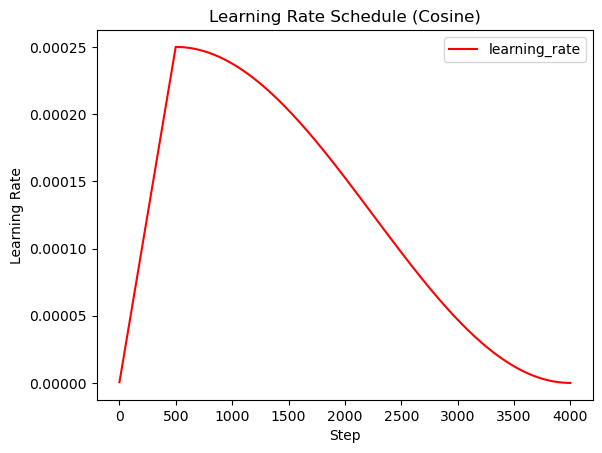

In [59]:
# compute lr
test_schedule = CosineSchedule(train_steps=4000, warmup_steps=500)
lrs = []
for step_num in range(4000):
    lrs.append(test_schedule.step())

# draw
plt.plot(lrs, 'r-', label='learning_rate')
plt.xlabel('Step')
plt.ylabel('Learning Rate')
plt.legend()
plt.title('Learning Rate Schedule (Cosine)')
plt.show()

이제 모델을 실제로 빌드해 봅시다.

In [60]:
# 모델 생성을 위한 라이브러리 설치
%pip install -q torchinfo

Note: you may need to restart the kernel to use updated packages.


In [61]:
# 모델 생성
try:
    from torchinfo import summary
except ImportError:
    summary = None
    print("torchinfo가 설치되어 있지 않습니다. `%pip install torchinfo`를 실행하세요.")

config.n_seq = 128
# 실제 SentencePiece vocab size에 맞춰 모델 vocab size를 설정합니다.
# 이 값이 맞지 않으면 MLM label이 vocab 범위를 넘어 loss 계산에서 오류가 날 수 있습니다.
if "REAL_VOCAB_SIZE" in globals():
    config.n_vocab = REAL_VOCAB_SIZE
config.i_pad = 0

print("model n_vocab:", config.n_vocab)
pre_train_model = build_model_pre_train(config)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pre_train_model.to(device)

enc_tokens_example = torch.randint(0, config.n_vocab, (10, config.n_seq), dtype=torch.long).to(device)
segments_example = torch.randint(0, 2, (10, config.n_seq), dtype=torch.long).to(device)

if summary is not None:
    summary(pre_train_model, input_data=(enc_tokens_example, segments_example))


model n_vocab: 8007


이제 본격적으로 학습을 진행합니다. 1 Epoch만 학습하는 데도 10분 이상의 상당한 시간이 소요될 것입니다. 메모리 오류가 날 수 있으니 배치 사이즈에도 유의해 주세요. 우리는 전체 데이터셋 중의 1/7 수준인 128,000건만 로딩해서 사용 중이라는 것을 기억합시다.

optimizer는 Adam을 사용하고, MLM과 NSP에 대한 loss와 accuracy를 알 수 있도록 하였습니다.

In [62]:
epochs = int(os.environ.get("BERT_PRETRAIN_EPOCHS", "1"))
batch_size = int(os.environ.get("BERT_PRETRAIN_BATCH_SIZE", "8"))

# optimizer
train_steps = math.ceil(len(pre_train_inputs[0]) / batch_size) * epochs
print("epochs:", epochs)
print("batch_size:", batch_size)
print("train_steps:", train_steps)

optimizer = optim.Adam(pre_train_model.parameters(), lr=0.0)
learning_rate_scheduler = CosineSchedule(
    optimizer=optimizer,
    train_steps=train_steps,
    warmup_steps=max(1, min(100, train_steps // 10 if train_steps >= 10 else 1)),
    max_lr=1e-4
)

loss_fn_nsp = nn.CrossEntropyLoss()


epochs: 50
batch_size: 8
train_steps: 25600


학습시킨 모델을 콜백 함수를 사용해 저장하고, 시각화해 봅시다.

In [63]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # GPU가 있으면 cuda 사용, 없으면 CPU

# np.memmap을 한 번에 GPU로 올리지 않고, DataLoader batch마다 device로 이동합니다.
pre_train_inputs_t = [torch.from_numpy(np.asarray(x)) for x in pre_train_inputs]
pre_train_labels_t = [torch.from_numpy(np.asarray(x)) for x in pre_train_labels]

train_dataset = TensorDataset(
    pre_train_inputs_t[0],
    pre_train_inputs_t[1],
    pre_train_labels_t[0],
    pre_train_labels_t[1]
)
train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    pin_memory=(device.type == "cuda")
)

pre_train_model.to(device)

history = {
    "nsp_loss": [],
    "mlm_loss": [],
    "nsp_acc": [],
    "mlm_acc": []
}

os.makedirs("work", exist_ok=True)

for epoch in range(epochs):
    pre_train_model.train()
    total_loss = 0.0
    total_nsp_loss = 0.0
    total_mlm_loss = 0.0
    total_nsp_acc = 0.0
    total_mlm_acc = 0.0

    for batch in train_dataloader:
        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch

        enc_tokens_batch = enc_tokens_batch.to(device, dtype=torch.long, non_blocking=True)
        segments_batch = segments_batch.to(device, dtype=torch.long, non_blocking=True)
        labels_nsp_batch = labels_nsp_batch.to(device, dtype=torch.long, non_blocking=True)
        labels_mlm_batch = labels_mlm_batch.to(device, dtype=torch.long, non_blocking=True)

        optimizer.zero_grad()

        logits_nsp, logits_mlm = pre_train_model(enc_tokens_batch, segments_batch)

        loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)
        loss_mlm = lm_loss(labels_mlm_batch, logits_mlm, ignore_index=0, scale=20.0)

        total_loss_batch = loss_nsp + loss_mlm
        total_loss += total_loss_batch.item()
        total_nsp_loss += loss_nsp.item()
        total_mlm_loss += loss_mlm.item()

        total_loss_batch.backward()
        optimizer.step()
        learning_rate_scheduler.step()

        nsp_acc = (logits_nsp.argmax(dim=-1) == labels_nsp_batch).float().mean()
        mlm_acc_value = lm_acc(labels_mlm_batch, logits_mlm, ignore_index=0)

        total_nsp_acc += nsp_acc.item()
        total_mlm_acc += mlm_acc_value.item()

    num_batches = len(train_dataloader)
    if num_batches == 0:
        raise RuntimeError("학습 batch가 0개입니다. pretrain 데이터 생성/로딩 결과를 확인해야 합니다.")

    # 결과 저장
    history["nsp_loss"].append(total_nsp_loss / num_batches)
    history["mlm_loss"].append(total_mlm_loss / num_batches)
    history["nsp_acc"].append(total_nsp_acc / num_batches)
    history["mlm_acc"].append(total_mlm_acc / num_batches)

    print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss / num_batches}, "
          f"NSP Loss: {total_nsp_loss / num_batches}, MLM Loss: {total_mlm_loss / num_batches}, "
          f"NSP Accuracy: {total_nsp_acc / num_batches}, MLM Accuracy: {total_mlm_acc / num_batches}")

    # 모델 저장
    torch.save(pre_train_model.state_dict(), f"work/bert_pre_train_epoch_{epoch+1}.pt")

Epoch 1/50 - Loss: 163.08336606621742, NSP Loss: 0.6924277530051768, MLM Loss: 162.39093831181526, NSP Accuracy: 0.525634765625, MLM Accuracy: 0.030455657925813284
Epoch 2/50 - Loss: 152.96439802646637, NSP Loss: 0.6675292112049647, MLM Loss: 152.2968688607216, NSP Accuracy: 0.5732421875, MLM Accuracy: 0.03367498513762257
Epoch 3/50 - Loss: 152.52764225006104, NSP Loss: 0.6410805074847303, MLM Loss: 151.88656216859818, NSP Accuracy: 0.594482421875, MLM Accuracy: 0.033148039602565404
Epoch 4/50 - Loss: 152.25083485245705, NSP Loss: 0.6367756426916458, MLM Loss: 151.61405923962593, NSP Accuracy: 0.6005859375, MLM Accuracy: 0.032945281524916936
Epoch 5/50 - Loss: 151.95817583799362, NSP Loss: 0.6395253269583918, MLM Loss: 151.31865048408508, NSP Accuracy: 0.59521484375, MLM Accuracy: 0.033617480112297926
Epoch 6/50 - Loss: 151.57561710476875, NSP Loss: 0.6378774652839638, MLM Loss: 150.93773931264877, NSP Accuracy: 0.59228515625, MLM Accuracy: 0.0334389222362006
Epoch 7/50 - Loss: 151.079

       nsp_loss    mlm_loss   nsp_acc   mlm_acc
epoch                                          
1      0.692428  162.390938  0.525635  0.030456
2      0.667529  152.296869  0.573242  0.033675
3      0.641081  151.886562  0.594482  0.033148
4      0.636776  151.614059  0.600586  0.032945
5      0.639525  151.318650  0.595215  0.033617
6      0.637877  150.937739  0.592285  0.033439
7      0.635348  150.444521  0.592773  0.033218
8      0.634847  149.967233  0.598389  0.032844
9      0.633061  149.554173  0.591797  0.033346
10     0.632350  149.175715  0.594482  0.032615
11     0.631512  148.817270  0.586670  0.034133
12     0.632335  148.373376  0.594238  0.034976
13     0.628480  147.920394  0.600098  0.036023
14     0.625253  147.557440  0.590820  0.036126
15     0.621872  147.191565  0.592285  0.037378
16     0.616021  146.795958  0.591064  0.037851
17     0.613319  146.497288  0.598389  0.038929
18     0.608140  146.112060  0.585938  0.039269
19     0.607200  145.760240  0.588379  0

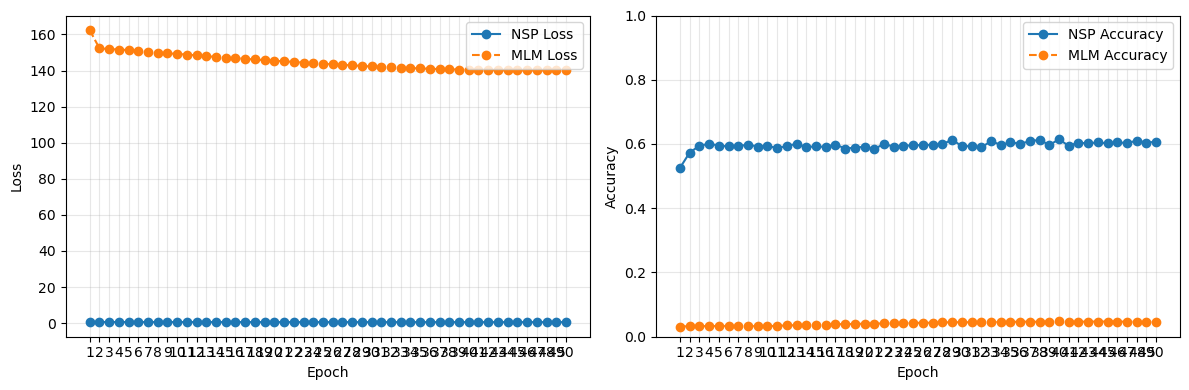

In [64]:
import matplotlib.pyplot as plt
import pandas as pd

# training result
if len(history["nsp_loss"]) == 0:
    raise RuntimeError("history가 비어 있습니다. 바로 위 학습 셀이 정상적으로 실행됐는지 확인해야 합니다.")

history_df = pd.DataFrame(history)
history_df.index = range(1, len(history_df) + 1)
history_df.index.name = "epoch"
print(history_df)

x = history_df.index.to_list()

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(x, history_df["nsp_loss"], marker="o", label="NSP Loss")
plt.plot(x, history_df["mlm_loss"], marker="o", linestyle="--", label="MLM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(x)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(x, history_df["nsp_acc"], marker="o", label="NSP Accuracy")
plt.plot(x, history_df["mlm_acc"], marker="o", linestyle="--", label="MLM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(x)
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 회고
- os.environ.setdefault("BERT_PRETRAIN_EPOCHS", "50")
- 에폭을 50으로 설정 시 성능 향상
- nsp_loss    mlm_loss   nsp_acc   mlm_acc
- 0.590590  140.042301  0.606934  0.047262 - 변경 후
- 0.633176  151.235998  0.596680  0.033507 - 변경 전